In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from datasets import load_dataset  ## datasets load krvane me help kregi


## 2. Load Dataset
Load the dair-ai/emotion dataset from Hugging Face. https://huggingface.co/datasets/dair-ai/emotion

In [3]:
emotion_dataset = load_dataset('dair-ai/emotion')
emotion_dataset


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [4]:
train_text      = emotion_dataset['train']['text']
train_label     = emotion_dataset['train']['label']

test_text       = emotion_dataset['test']['text']
test_label      = emotion_dataset['test']['label']

In [5]:
label_names = emotion_dataset['train'].features['label'].names

In [6]:
for i in train_label:
    print(label_names[i])

sadness
sadness
anger
love
anger
sadness
surprise
fear
joy
love
sadness
joy
anger
sadness
joy
joy
sadness
sadness
sadness
fear
anger
fear
joy
joy
anger
sadness
sadness
sadness
anger
joy
joy
fear
surprise
anger
joy
joy
joy
joy
anger
joy
joy
joy
joy
joy
sadness
sadness
joy
love
joy
anger
joy
sadness
anger
fear
joy
sadness
sadness
surprise
joy
joy
joy
love
fear
fear
surprise
anger
anger
sadness
love
joy
sadness
sadness
joy
sadness
sadness
sadness
joy
joy
joy
anger
sadness
anger
anger
anger
joy
joy
joy
joy
sadness
fear
love
anger
sadness
anger
love
sadness
joy
joy
sadness
anger
love
joy
joy
joy
sadness
joy
joy
joy
joy
sadness
joy
joy
love
sadness
sadness
joy
joy
sadness
joy
joy
fear
fear
fear
sadness
love
joy
joy
love
fear
surprise
joy
joy
joy
joy
anger
fear
joy
anger
love
anger
sadness
joy
sadness
anger
joy
surprise
sadness
anger
anger
sadness
joy
fear
joy
joy
fear
sadness
surprise
surprise
joy
anger
fear
anger
sadness
anger
sadness
fear
sadness
joy
surprise
fear
joy
anger
joy
anger
joy
f

In [7]:
df_train = pd.DataFrame({'text': train_text, 'label': [label_names[i] for i in train_label]})
df_test = pd.DataFrame({'text': test_text, 'label': [label_names[i] for i in test_label]})

In [8]:
df_train.head()


,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [9]:
df_train.isnull().sum()

text     0
label    0
dtype: int64

## EDA

<Axes: xlabel='label', ylabel='count'>

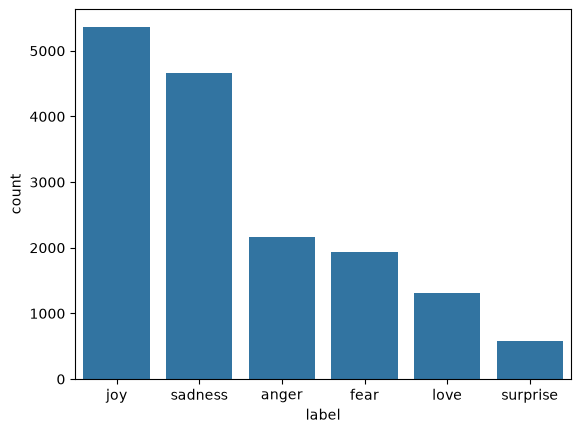

In [10]:
sns.countplot(x='label', data=df_train,order=df_train['label'].value_counts().index )

## Data Preprocessing - Using NLP

In [11]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words = 10000

tokenizer = Tokenizer(num_words=max_words, oov_token='<unk>')
tokenizer.fit_on_texts(df_train['text'])

train_sequences = tokenizer.texts_to_sequences(df_train['text'])
test_sequences = tokenizer.texts_to_sequences(df_test['text'])

In [12]:
train_sequences

[[2, 139, 3, 679],
 [2,
  40,
  101,
  60,
  8,
  15,
  494,
  5,
  15,
  3496,
  553,
  32,
  60,
  61,
  128,
  148,
  76,
  1480,
  4,
  22,
  1255],
 [17, 3060, 7, 1149, 5, 286, 2, 3, 495, 438],
 [2, 24, 165, 8, 665, 27, 6, 4158, 2, 59, 47, 9, 13, 22, 72, 30, 6, 3497],
 [2, 24, 8, 1065],
 [73, 48, 8, 7, 56, 521, 319, 328, 158, 161, 9, 20],
 [73,
  48,
  329,
  35,
  7401,
  35,
  196,
  7402,
  888,
  4,
  73,
  2475,
  1384,
  7,
  159,
  1885,
  19,
  2,
  117,
  3,
  14,
  15,
  455],
 [2, 3, 29, 439, 27, 78, 29, 7, 1686, 35, 29, 760, 29, 7, 193, 267, 374],
 [2,
  21,
  48,
  25,
  5260,
  16,
  215,
  2,
  3,
  9,
  5260,
  99,
  5261,
  135,
  4,
  132,
  7,
  1038,
  4159],
 [2, 3, 666, 94],
 [2, 3, 14, 2, 21, 5, 80, 6, 733, 2, 93, 544, 304, 84],
 [2,
  39,
  3,
  9,
  483,
  22,
  7,
  530,
  440,
  4,
  9,
  2,
  40,
  920,
  5,
  21,
  69,
  840,
  10,
  1886,
  3061],
 [2, 70, 13, 90, 6, 5262, 52, 10, 193, 5, 3, 610],
 [2, 3, 339, 456, 2, 93, 32, 4160],
 [2,
  21,
  4161,

In [13]:
padded_train_sequences = pad_sequences(train_sequences, padding='post', maxlen=50,truncating='post')
padded_test_sequences = pad_sequences(test_sequences, padding='post', maxlen=50,truncating='post')
padded_train_sequences

array([[   2,  139,    3, ...,    0,    0,    0],
       [   2,   40,  101, ...,    0,    0,    0],
       [  17, 3060,    7, ...,    0,    0,    0],
       ...,
       [   2,    3,  327, ...,    0,    0,    0],
       [   2,    3,   14, ...,    0,    0,    0],
       [   2,   47,    7, ...,    0,    0,    0]])

In [14]:
train_labels = np.array(train_label)

test_labels = np.array(test_label)
train_labels


array([0, 0, 3, ..., 1, 3, 0])

In [15]:
num_classes = len(np.unique(train_labels))
num_classes

6

In [16]:
print(f"Vocabulary Size: {len(tokenizer.word_index)}")
print(f"Max Sentence Length: {padded_train_sequences.shape[1]}")

Vocabulary Size: 15213
Max Sentence Length: 50


 ## 5. shared Traing Utilities
compute balanced class weights to handle dataset skew and setup early stoping 

In [17]:
from sklearn.utils import class_weight 
class_weights = class_weight.compute_class_weight(
                                                  class_weight ='balanced', 
                                                  classes      =np.unique(train_labels),
                                                    y          =train_labels
                                                    )

In [18]:
class_weight_dict = dict(enumerate(class_weights))

In [19]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
early_stopping = EarlyStopping(
    monitor   ='val_loss',
    patience  =3, 
    restore_best_weights=True
    )

## 6. Plain Foundational Models
train plain(non-bidirectional) Simple RNN, Standard LSTM and Standard GRU models

In [47]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,SimpleRNN, LSTM,GRU, Dense, Dropout
rnn_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=50),
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
        Dropout(0.5),
    Dense(units=num_classes, activation='softmax')
])


d:\emotion-classification-nlp\venv\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [49]:
rnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [50]:
rnn_model.fit(
    padded_train_sequences,
    train_labels,
    epochs=20,
    batch_size=32,
    validation_data=(padded_test_sequences, test_labels),
    
    class_weight=class_weight_dict,
    callbacks=[early_stopping]

)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 37ms/step - accuracy: 0.1561 - loss: 2.0340 - val_accuracy: 0.0780 - val_loss: 1.7633
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.1475 - loss: 1.8754 - val_accuracy: 0.0355 - val_loss: 1.8357
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.1336 - loss: 1.8216 - val_accuracy: 0.0350 - val_loss: 1.8023
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 37ms/step - accuracy: 0.1259 - loss: 1.8060 - val_accuracy: 0.2830 - val_loss: 1.7403
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.1411 - loss: 1.8035 - val_accuracy: 0.2845 - val_loss: 1.7505
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.1488 - loss: 1.7989 - val_accuracy: 0.0355 - val_loss: 1.7918
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.1398 - loss: 1.8015 - val_accuracy: 0.0805 - val_loss: 1.8305


In [58]:
rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequences, test_labels)
print(f"RNN Test Loss: {rnn_loss:.4f}, RNN Test Accuracy: {rnn_accuracy:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2830 - loss: 1.7403
RNN Test Loss: 1.7403, RNN Test Accuracy: 0.2830


## Standard LSTM

In [51]:
lstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=50),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax')
])


In [52]:
lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
lstm_model.fit(
    padded_train_sequences,
    train_labels,
    epochs=20,
    batch_size=32,
    validation_data=(padded_test_sequences, test_labels),
    
    class_weight=class_weight_dict,
    callbacks=[early_stopping]

)



Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 30s 57ms/step - accuracy: 0.1583 - loss: 1.7954 - val_accuracy: 0.0330 - val_loss: 1.8009
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 56ms/step - accuracy: 0.1423 - loss: 1.7927 - val_accuracy: 0.1190 - val_loss: 1.7898
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 57ms/step - accuracy: 0.1614 - loss: 1.7932 - val_accuracy: 0.0845 - val_loss: 1.7970
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 26s 51ms/step - accuracy: 0.1827 - loss: 1.7906 - val_accuracy: 0.1335 - val_loss: 1.8145
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step - accuracy: 0.1940 - loss: 1.7640 - val_accuracy: 0.2340 - val_loss: 1.7528
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 50ms/step - accuracy: 0.2565 - loss: 1.6311 - val_accuracy: 0.3880 - val_loss: 1.5205
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.3243 - loss: 1.4157 - val_accuracy: 0.4810 - val_loss: 1.3095
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.4186 - loss: 1.1029 - 

In [59]:
lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequences, test_labels)
print(f"LSTM Test Loss: {lstm_loss:.4f}, LSTM Test Accuracy: {lstm_accuracy:.4f}")



63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9095 - loss: 0.3130
LSTM Test Loss: 0.3130, LSTM Test Accuracy: 0.9095


## Standard GRU

In [57]:
gru_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=50),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax')
])

gru_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)



gru_model.fit(
    padded_train_sequences,
    train_labels,
    epochs=20,
    batch_size=32,
    validation_data=(padded_test_sequences, test_labels),
    
    class_weight=class_weight_dict,
    callbacks=[early_stopping]

)
gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequences, test_labels)
print(f"GRU Test Loss: {gru_loss:.4f}, GRU Test Accuracy: {gru_accuracy:.4f}")

Epoch 1/20


d:\emotion-classification-nlp\venv\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


500/500 ━━━━━━━━━━━━━━━━━━━━ 31s 53ms/step - accuracy: 0.1346 - loss: 1.7962 - val_accuracy: 0.3490 - val_loss: 1.7820
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 26s 53ms/step - accuracy: 0.1560 - loss: 1.7954 - val_accuracy: 0.1395 - val_loss: 1.7815
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 56ms/step - accuracy: 0.1636 - loss: 1.7939 - val_accuracy: 0.0360 - val_loss: 1.8058
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 26s 52ms/step - accuracy: 0.1584 - loss: 1.7922 - val_accuracy: 0.0685 - val_loss: 1.7994
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 47ms/step - accuracy: 0.1640 - loss: 1.7800 - val_accuracy: 0.1490 - val_loss: 1.7966
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.1395 - loss: 1.7815
GRU Test Loss: 1.7815, GRU Test Accuracy: 0.1395


In [61]:
results_df=pd.DataFrame({
    'Model': ['RNN', 'LSTM', 'GRU'],
    'Test Loss': [rnn_loss, lstm_loss, gru_loss],
    'Test Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy]
}).sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)
results_df

,Model,Test Loss,Test Accuracy
0,LSTM,0.313025,0.9095
1,RNN,1.740299,0.2830
2,GRU,1.781501,0.1395


## Advanced Bidirectional GRU
Enhance GRU with Bidirectional layers embeddings and 0.5 dropout regularization

In [62]:
from tensorflow.keras.layers import Bidirectional
BiGRU=Sequential([
    Embedding(input_dim=max_words, output_dim=300, input_length=50),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
   
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

BiGRU.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

BiGRU.summary()

d:\emotion-classification-nlp\venv\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_14 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [63]:
BiGRU.fit(
    padded_train_sequences,
    train_labels,
    epochs=20,
    batch_size=32,
    validation_data=(padded_test_sequences, test_labels),
    
    class_weight=class_weight_dict,
    callbacks=[early_stopping]

)



Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 76s 140ms/step - accuracy: 0.4263 - loss: 1.2682 - val_accuracy: 0.8035 - val_loss: 0.6315
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 69s 138ms/step - accuracy: 0.8644 - loss: 0.3826 - val_accuracy: 0.8935 - val_loss: 0.3248
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 57s 114ms/step - accuracy: 0.9219 - loss: 0.2157 - val_accuracy: 0.9145 - val_loss: 0.2355
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 56s 112ms/step - accuracy: 0.9470 - loss: 0.1469 - val_accuracy: 0.9225 - val_loss: 0.2205
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 54s 108ms/step - accuracy: 0.9583 - loss: 0.1109 - val_accuracy: 0.9160 - val_loss: 0.2399
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 54s 107ms/step - accuracy: 0.9653 - loss: 0.0916 - val_accuracy: 0.9295 - val_loss: 0.1968
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 54s 108ms/step - accuracy: 0.9742 - loss: 0.0700 - val_accuracy: 0.9250 - val_loss: 0.2810
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 54s 109ms/step - accuracy: 0.9796 - loss: 0

In [64]:
BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequences, test_labels)
print(f"BiGRU Test Loss: {BiGRU_loss:.4f}, BiGRU Test Accuracy: {BiGRU_accuracy:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9295 - loss: 0.1968
BiGRU Test Loss: 0.1968, BiGRU Test Accuracy: 0.9295


In [70]:
from sklearn.metrics import classification_report

y_pred = BiGRU.predict(padded_test_sequences)
y_pred = np.argmax(y_pred, axis=1)

print(classification_report(test_labels, y_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       581
           1       0.97      0.92      0.94       695
           2       0.79      0.90      0.84       159
           3       0.92      0.94      0.93       275
           4       0.90      0.89      0.89       224
           5       0.69      0.92      0.79        66

    accuracy                           0.93      2000
   macro avg       0.88      0.92      0.89      2000
weighted avg       0.93      0.93      0.93      2000



## Overall Evaluation & Bias Analysis

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step


<Axes: >

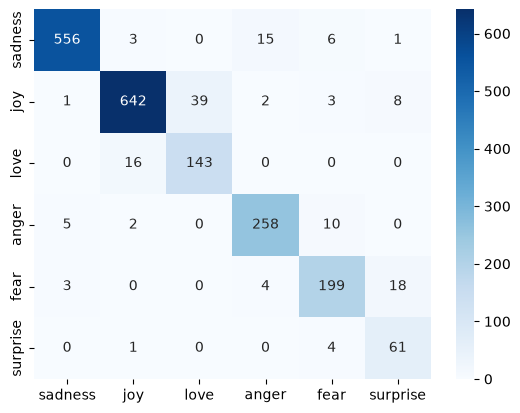

In [65]:
from sklearn.metrics import  confusion_matrix
BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequences), axis=1)

sns.heatmap(confusion_matrix(test_labels, BiGRU_predictions), annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)

## Final Predictions


In [77]:
sample_text = [
    "I got the job I always wanted!",
    "Today has been a wonderful day.",
    "I can't stop smiling after hearing the good news.",

    "I lost someone very close to me.",
    "Nothing seems to be going right today.",
    "I feel lonely and hopeless.",

    "This is absolutely unacceptable!",
    "I am really frustrated with what happened.",
    "How could they treat me like this?",

    "I heard a strange noise outside my room.",
    "I am nervous about what might happen.",
    "Walking alone in this place makes me uncomfortable.",

    "I never expected this to happen!",
    "Wow, I didn't see that coming.",
    "The news completely shocked me.",

    "I really appreciate everything you have done for me.",
    "I care deeply about my family.",
    "You are one of the most important people in my life."
]

sample_sequences = tokenizer.texts_to_sequences(sample_text)

sample_padded_sequences = pad_sequences(
    sample_sequences,
    maxlen=50,
    padding='post',
    truncating='post'
)

sample_predictions = np.argmax(
    lstm_model.predict(sample_padded_sequences),
    axis=1
)

for i in range(len(sample_text)):
    print(
        f"Text: {sample_text[i]}\n"
        f"Predicted Emotion: {label_names[sample_predictions[i]]}"
    ) 

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
Text: I got the job I always wanted!
Predicted Emotion: love
Text: Today has been a wonderful day.
Predicted Emotion: joy
Text: I can't stop smiling after hearing the good news.
Predicted Emotion: joy
Text: I lost someone very close to me.
Predicted Emotion: sadness
Text: Nothing seems to be going right today.
Predicted Emotion: anger
Text: I feel lonely and hopeless.
Predicted Emotion: sadness
Text: This is absolutely unacceptable!
Predicted Emotion: anger
Text: I am really frustrated with what happened.
Predicted Emotion: anger
Text: How could they treat me like this?
Predicted Emotion: anger
Text: I heard a strange noise outside my room.
Predicted Emotion: surprise
Text: I am nervous about what might happen.
Predicted Emotion: fear
Text: Walking alone in this place makes me uncomfortable.
Predicted Emotion: fear
Text: I never expected this to happen!
Predicted Emotion: joy
Text: Wow, I didn't see that coming.
Predicted Emotion: anger
Text: The 

In [78]:
sample_text = [
    "I got the job I always wanted!",
    "Today has been a wonderful day.",
    "I can't stop smiling after hearing the good news.",

    "I lost someone very close to me.",
    "Nothing seems to be going right today.",
    "I feel lonely and hopeless.",

    "This is absolutely unacceptable!",
    "I am really frustrated with what happened.",
    "How could they treat me like this?",

    "I heard a strange noise outside my room.",
    "I am nervous about what might happen.",
    "Walking alone in this place makes me uncomfortable.",

    "I never expected this to happen!",
    "Wow, I didn't see that coming.",
    "The news completely shocked me.",

    "I really appreciate everything you have done for me.",
    "I care deeply about my family.",
    "You are one of the most important people in my life."
]

sample_sequences = tokenizer.texts_to_sequences(sample_text)

sample_padded_sequences = pad_sequences(
    sample_sequences,
    maxlen=50,
    padding='post',
    truncating='post'
)

sample_predictions = np.argmax(
    BiGRU.predict(sample_padded_sequences),
    axis=1
)

for i in range(len(sample_text)):
    print(
        f"Text: {sample_text[i]}\n"
        f"Predicted Emotion: {label_names[sample_predictions[i]]}"
    ) 

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 634ms/step
Text: I got the job I always wanted!
Predicted Emotion: sadness
Text: Today has been a wonderful day.
Predicted Emotion: joy
Text: I can't stop smiling after hearing the good news.
Predicted Emotion: sadness
Text: I lost someone very close to me.
Predicted Emotion: sadness
Text: Nothing seems to be going right today.
Predicted Emotion: anger
Text: I feel lonely and hopeless.
Predicted Emotion: sadness
Text: This is absolutely unacceptable!
Predicted Emotion: anger
Text: I am really frustrated with what happened.
Predicted Emotion: anger
Text: How could they treat me like this?
Predicted Emotion: joy
Text: I heard a strange noise outside my room.
Predicted Emotion: surprise
Text: I am nervous about what might happen.
Predicted Emotion: fear
Text: Walking alone in this place makes me uncomfortable.
Predicted Emotion: fear
Text: I never expected this to happen!
Predicted Emotion: anger
Text: Wow, I didn't see that coming.
Predicted Emotion: joy
Text: